#**Linear Regression Practical Implementation**

**What:??**


Linear regression is a statistical method for modeling the relationship between a dependent variable (what you're trying to predict) and one or more independent variables (the inputs), by fitting a straight line (or plane, in higher dimensions) through the data.

The basic idea

For the simplest case — one input variable — you're looking for the line that best fits a scatter of points:

𝑦=𝑚𝑥+𝑏

-> y is the outcome you want to predict

-> x is the input variable

-> m is the slope (how much y changes for each unit change in x)

-> b is the intercept (the value of y when x=0)


**Why:??**

We use linear regression because it's simple, easy to interpret, and computationally efficient. When we want to understand how one variable affects another, and the relationship is roughly linear, it's usually the first and best starting point.

With more detail (good for interviews):

"There are several reasons:

1. Simplicity — The math and logic are straightforward; no complex machinery needed to understand it.
2. Interpretability — You can clearly see how much each input variable affects the output. For example, 'each extra hour of studying increases the score by 5 points' is easy to understand and explain to others.
3. Baseline model — In machine learning, it's often used as a baseline. You try the simple model first, then check whether a more complex model (like neural networks) actually performs better — if not, why add the complexity?
4. Works with less data and compute — Compared to more complex models, it performs reasonably well even with limited data and computing power.
5. Prediction plus insight — It doesn't just give you a prediction; it also tells you which variables matter most and by how much."

One-liner if you need it really short:

Because it's the simplest, most reliable way to understand and predict relationships between variables.


**Use:??**


Linear regression is used wherever we need to predict a numeric value based on one or more input variables, and the relationship between them is roughly linear.

Common real-world use cases:

1. Business & Sales — Predicting sales based on advertising spend, or forecasting revenue based on past trends.
2. Real Estate — Predicting house prices based on factors like size, location, and number of bedrooms.
3. Finance — Predicting stock prices or assessing risk based on economic indicators.
4. Healthcare — Predicting a patient's blood pressure based on age, weight, and other factors.
5. Education — Predicting exam scores based on study hours or attendance.
6. Marketing — Understanding how much a change in price affects product demand.
7. Sports Analytics — Predicting a player's performance based on training hours, past stats, etc.
8. Machine Learning Baseline — Used as a starting/reference model before trying more complex algorithms.

One-liner if you need it short:

It's used to predict numeric outcomes — like sales, prices, or scores — based on known input factors, wherever the relationship between them is roughly a straight line.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
dataset=pd.read_csv('HousingData.csv')

In [ ]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
# Check columns data types to see why num_feature is empty
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


Jaise ki aap dekh sakte hain, saare columns `float64` ya `int64` hain. Agar aap numeric features ki list chahte hain, toh aap 'object' ki jagah `np.number` check kar sakte hain.

In [ ]:
dataset.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
# Iterating through columns that have null values
for feature in dataset.columns:
    if dataset[feature].isnull().sum() > 0:
        # Fill missing values with the median of that specific column
        dataset[feature] = dataset[feature].fillna(dataset[feature].median())

# Verify if nulls are gone
print(dataset.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
# Independent and Dependent feature
x=dataset.drop(columns='MEDV',axis=1)
y=dataset['MEDV']

In [ ]:
y

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
# Train test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [ ]:
## standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(x_train)

In [ ]:
x_test=scaler.transform(x_test)

**Cross-validation ka use model ki performance ko more reliably evaluate karne ke liye karte hain.**

Simple example:

Agar hum sirf ek baar:

X_train, X_test, y_train, y_test

karke model train/test karein, to performance sirf us particular train-test split par depend karegi.

**Cross-validation kya karta hai?**

Suppose 5-Fold Cross-Validation:
Dataset
   ↓
5 parts (Folds)

Fold 1 → Test | 2,3,4,5 → Train

Fold 2 → Test | 1,3,4,5 → Train


Fold 3 → Test | 1,2,4,5 → Train

Fold 4 → Test | 1,2,3,5 → Train

Fold 5 → Test | 1,2,3,4 → Train

Model 5 baar train aur evaluate hota hai.

Phir:

Score 1

Score 2

Score 3

Score 4

Score 5
   ↓
Mean Score

**Main reason**

"Kya mera model kisi ek lucky/unlucky train-test split par hi achha perform kar raha hai, ya generally achha perform karta hai?"

Ye pata karne ke liye cross-validation use karte hain.




**MSE kya karta hai?**

Actual target aur predicted target ke difference ka square karke average:

$$ MSE = \frac{1}{n}\sum(y_{actual}-y_{predicted})^2 $$

neg_mean_squared_error Mean Squared Error (MSE) ka negative version hai.

**MSE jitna kam → model utna better. ✅**

-->Phir neg_mean_squared_error negative kyun?

''Scikit-learn ke cross_val_score() mein higher score ko better maana jata hai. Lekin MSE mein lower better hota hai.''

Isliye sklearn MSE ko negative karke return karta hai:

scoring="neg_mean_squared_error"

**Example:**

Actual MSE = 25
neg_mean_squared_error = -25

Aur:

Actual MSE = 10
neg_mean_squared_error = -10

-10 better hai than -25, kyunki actual MSE 10 hai, jo smaller hai.



Ye 5 folds par MSE calculate karega, lekin negative form mein scores dega.

Agar actual MSE chahiye:

mse = -scores

**Ek line mein yaad rakho:**

neg_mean_squared_error = MSE ko negative karke dena, taaki sklearn ka "higher score = better" rule maintain rahe.

In [ ]:
from sklearn.linear_model import LinearRegression
## Cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
regression=LinearRegression()
regression.fit(x_train,y_train)

LinearRegression()

In [ ]:
mse=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [ ]:
np.mean(mse)

np.float64(-26.775997757296977)

In [ ]:
## prediction
red_pred=regression.predict(x_test)

In [ ]:
red_pred

array([28.74796697, 37.04276981, 15.23648947, 25.57965227, 18.4598692 ,
       22.95780707, 17.76850542, 14.38571217, 22.03723629, 20.796854  ,
       25.16699768, 18.51966638, -6.22880411, 21.87874844, 19.05911392,
       25.92922218, 19.3934137 ,  5.61048116, 40.70614094, 17.14502899,
       25.42004954, 30.2613306 , 11.39021059, 23.35145746, 17.4879536 ,
       15.09897977, 21.9909183 , 14.50652624, 22.83647869, 19.54687218,
       22.17131402, 25.26099979, 24.99671977, 17.36761266, 16.16822936,
       17.36263859, 30.95455472, 20.38362751, 24.70846444, 23.39340539,
       14.4632438 , 31.68885585, 42.62429658, 17.98408565, 27.34827935,
       16.52654044, 13.96867708, 26.49229684, 19.68936425, 30.28704199,
       21.09514632, 33.2905181 , 15.96674251, 26.26129713, 39.53495509,
       22.45120293, 18.43260546, 32.87791268, 25.23294135, 12.9442509 ,
       22.82835929, 30.8937041 , 31.9036883 , 16.74514578, 21.27346987,
       17.15682196, 19.93344794, 26.3380121 , 31.15946499, 11.74

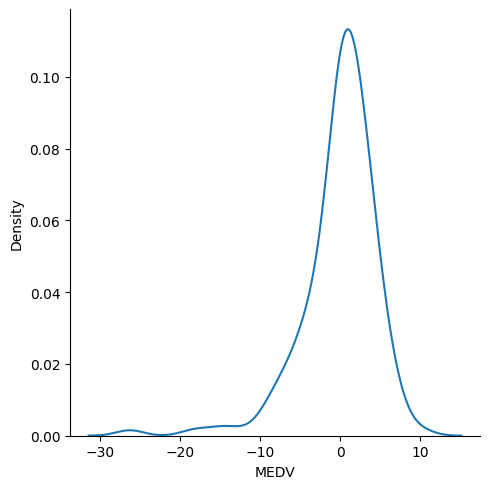

In [ ]:
import seaborn as sns
# Using displot which supports the 'kind' argument
sns.displot(red_pred - y_test, kind='kde')
plt.show()

**R²** (R-squared) ka use Machine Learning mein Regression model ki performance check karne ke liye karte hain.

Simple language mein:

R² ye batata hai ki hamara model target variable (y) ke variation ko kitna achhe se explain kar pa raha hai.

Example:

R² = 0.90 → Model 90% variation explain kar raha hai → achha model

R² = 0.50 → Model 50% variation explain kar raha hai

R² = 0 → Model kuch khaas explain nahi kar pa raha

R² < 0 → Model bahut poor perform kar raha hai
Formula:
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

Yaad rakhne wali line:

R² batata hai ki hamara Regression model target variable ke variation ko kitne percent tak explain kar raha hai.

Generally, R² jitna 1 ke close hoga, model utna better hoga.

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
score=r2_score( y_test, red_pred )

In [ ]:
score

0.7076438632327412

# **Ridge Regression Algorithm**



Ridge Regression is a modified version of linear regression that helps deal with **overfitting** and **multicollinearity** (when input variables are highly correlated with each other).

**The Core Idea**

Regular linear regression tries to minimize just the error (sum of squared differences between actual and predicted values). Ridge regression adds a **penalty term** to that error function, which discourages the model from assigning very large weights (coefficients) to the input variables.

**The Formula**

Normal linear regression minimizes:

Error = Sum(y_actual - y_predicted)^2

Ridge regression minimizes:

Error = Sum(y_actual - y_predicted)^2 + lambda * Sum(coefficients)^2

Where:
- lambda (regularization parameter) — controls how much penalty to apply
- coefficients are the slopes of the model
- The second term is called the **L2 penalty** (sum of squared coefficients)

**Why This Helps**

- If lambda = 0, ridge regression becomes exactly the same as normal linear regression.
- As lambda increases, the model shrinks the coefficients closer to zero (but never exactly zero), which makes the model simpler and less likely to overfit.
- This is especially useful when you have many input variables, or when some variables are highly correlated with each other (multicollinearity), which can make normal linear regression unstable.

**Ridge vs Lasso Regression**

- **Ridge** shrinks coefficients but keeps all variables (none become exactly zero).
- **Lasso** (a similar technique) can shrink some coefficients all the way to zero, effectively removing less important variables.

**Simple Analogy**

Think of it like this: normal linear regression tries to fit the data as tightly as possible, even if that means some coefficients become very large and sensitive to small changes in the data. Ridge regression says "fit the data well, but also keep the coefficients small and controlled" — trading a little bit of fit accuracy for a more stable, generalizable model.

**When to Use It**

- When you have many features, especially ones that are correlated with each other
- When your regular linear regression model is overfitting the training data
- When you want a more stable model that generalizes better to new data


**GridSearchCV:??**

GridSearchCV ka Use Kyun Karte Hain?

GridSearchCV (Scikit-learn ka ek tool) hyperparameter tuning ke liye use hota hai — yaani best hyperparameters dhundhne ke liye jo model ko sabse achha perform karwaye.

Main Uses:
1. Hyperparameter Tuning

Har ML model mein kuch hyperparameters hote hain jo humein manually set karne padte hain (jaise n_estimators, max_depth, learning_rate etc.). GridSearchCV automatically best combination dhundh leta hai.

2. Exhaustive Search

Ye ek grid (combinations ka set) banata hai aur har possible combination ko try karta hai — isliye naam "Grid" Search hai.

3. Cross-Validation ke saath

"CV" ka matlab hai Cross-Validation. Ye sirf hyperparameters try nahi karta, balki har combination ko k-fold cross-validation se validate bhi karta hai — isse overfitting ka risk kam hota hai.


**Fayde (Advantages):**
Point	                   Explanation
✅ Automated-> Manually try-and-error nahi karna padta
✅ Cross-validation->	Overfitting kam hota hai, reliable results milte hain
✅ Best combination->	Systematically best hyperparameters milte hain


**Nuksan (Disadvantages):**
Point	Explanation
❌ Slow/Expensive-> Agar grid bada hai, toh bahut time lagta hai (computationally costly)
❌ Curse of dimensionality-> Zyada parameters + zyada values = combinations exponentially badh jaate hain

**Alternative:**

Agar grid bahut bada ho aur time kam ho, toh RandomizedSearchCV use kar sakte hain — jo random combinations try karta hai (faster, but less exhaustive).

**Hyperparameter Tuning Kya Hota Hai??**

Pehle samajhte hain Parameter vs Hyperparameter ka difference, phir tuning samjhenge.

| 🔹 **Parameter**                                                 | ⚙️ **Hyperparameter**                                                              |
| ---------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| **Model training ke during automatically learn hota hai.**       | **Training se pehle manually set kiya jata hai.**                                  |
| Iski value **data ke basis par model khud calculate** karta hai. | Iski value **experience, experimentation ya tuning** ke basis par decide hoti hai. |
| Training ke saath parameters **update hote rehte hain.**         | Training ke dauran hyperparameters **automatically update nahi hote.**             |
| Model ke **actual learning process** ko represent karta hai.     | Model ke **learning process ko control** karta hai.                                |
| 🎯 **Goal:** Data ke patterns ko learn karna.                    | 🎯 **Goal:** Model ki performance ko improve karna.                                |
| 🧠 Example: **Weights, Biases**                                  | 🛠️ Example: **Learning Rate, Batch Size, Number of Epochs**                       |
| 📈 Linear Regression: **Slope (m), Intercept (c)**               | 🌳 Random Forest: **n_estimators, max_depth**                                      |
| **Model khud decide karta hai.**                                 | **Hum model ko decide karke dete hain.**                                           |
🧠 One-Line Trick

Parameter → Model khud seekhta hai 🤖
Hyperparameter → Hum model ko pehle se set karke dete hain ⚙️

Example:

i. Linear Regression: y = mx + c → m aur c parameters hain (model khud calculate karta hai)


ii. Random Forest: n_estimators = 100 → ye hyperparameter hai (aapne pehle se decide kiya)

**Hyperparameter Tuning Kya Hai?**

Hyperparameter Tuning ek process hai jisme hum best hyperparameter values dhundhte hain taaki model best performance de.

Simple shabdon mein: "Model ke settings (dials/knobs) ko adjust karna taaki wo sabse accha result de."

| 🤖 **Model**       | ⚙️ **Important Hyperparameters**                         | 💡 **Simple Meaning**                                                               |
| ------------------ | -------------------------------------------------------- | ----------------------------------------------------------------------------------- |
| **Ridge / Lasso**  | `alpha`                                                  | Regularization ki strength control karta hai                                        |
| **Decision Tree**  | `max_depth`, `min_samples_split`                         | Tree ki depth aur split hone ki condition control karta hai                         |
| **Random Forest**  | `n_estimators`, `max_depth`, `max_features`              | Trees ki quantity, depth aur features ka selection control karta hai                |
| **SVM**            | `C`, `kernel`, `gamma`                                   | Margin, decision boundary aur kernel behaviour control karta hai                    |
| **Neural Network** | `learning_rate`, `batch_size`, `epochs`, `hidden_layers` | Learning speed, batch size, training rounds aur network structure control karta hai |
| **KNN**            | `n_neighbors (k)`                                        | Prediction ke liye kitne nearest neighbours use honge, ye decide karta hai          |

**Hyperparameter Tuning Kyun Zaroori Hai (Use)?**

1. Overfitting/Underfitting Avoid Karna


i. Galat hyperparameters se model overfit (training data ratta maar le) ya underfit (kuch seekhe hi nahi) ho sakta hai.


ii. Sahi tuning se model balance mein aata hai.


2. Best Model Performance

i. Same algorithm, different hyperparameters = bahut different results.


ii. Jaise Random Forest mein n_estimators=10 vs n_estimators=500 — performance bahut alag hogi.


3. Generalization Improve Karna


i. Tuned model naye/unseen data par better perform karta hai.

4. Resource Efficiency
Sahi hyperparameters se model fast train hota hai bina accuracy compromise kiye.

**Kaise Karte Hain Tuning? (Methods)**
1. Manual Tuning

Khud try-and-error se values change karna (slow, inefficient).

2. GridSearchCV

Sabhi possible combinations try karta hai (exhaustive).

3. RandomizedSearchCV

Random combinations try karta hai (faster than Grid, less exhaustive).

4. Bayesian Optimization

Smart approach — pehle results ke basis par next best guess karta hai (jaise Optuna, Hyperopt).

One-Line Summary:

Hyperparameter Tuning = Model ke "settings" ko systematically test karke best combination dhundhna, taaki model sabse accurate aur generalized result de.

**Achha Point! Ye Clarify Karte Hain**

Nahi, simple Linear Regression mein Cross Validation hyperparameter tuning ke liye nahi hota — kyunki plain Linear Regression mein koi hyperparameter hota hi nahi hai!

Do Cases Samajhte Hain:



**Case 1: Simple Linear Regression (No Hyperparameters)**


Yahan CV ka use sirf model performance evaluate karne ke liye hota hai:

1. Model kitna generalize kar raha hai (overfitting/underfitting check)
2. Different data splits par consistent performance de raha hai ya nahi
3. Ek reliable performance estimate milta hai (single train-test split se better)

Isme tuning nahi ho rahi — sirf evaluation ho rahi hai!



**Case 2: Regularized Linear Regression (Ridge/Lasso) — Hyperparameters Hote Hain**

Agar aap Ridge Regression ya Lasso Regression use karte ho, tab hyperparameter hota hai — jaise alpha (regularization strength).


Yahan CV GridSearchCV ke andar use ho raha hai, isliye ye hyperparameter tuning ke liye hai.


| 🎯 **Scenario**                                  | 🔄 **CV ka Purpose**                                          | ⚙️ **Hyperparameter Tuning?** | 💡 **Explanation**                                                                                            |
| ------------------------------------------------ | ------------------------------------------------------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Simple Linear Regression + `cross_val_score`** | Model ki **performance evaluate** karna                       | ❌ **Nahi**                    | Yahan CV ka use sirf ye check karne ke liye hai ki model unseen data par kaisa perform karta hai.             |
| **Ridge/Lasso + `GridSearchCV`**                 | Different parameter values ko **CV ke through compare** karna | ✅ **Haan**                    | `alpha` ki different values test hoti hain aur best `alpha` select kiya jata hai.                             |
| **Simple Linear Regression + `GridSearchCV`**    | CV ke through scores calculate honge                          | ❌ **Generally useful nahi**   | Agar tune karne ke liye koi meaningful hyperparameter nahi hai, to `GridSearchCV` ka main benefit nahi milta. |


🧠 Yaad rakhne ka simple rule

cross_val_score → Performance Evaluation 🔍
GridSearchCV → Hyperparameter Tuning + Cross-Validation ⚙️

CV = Model ko check karo
GridSearchCV = Best settings dhoondo + model ko check karo


In [ ]:
from sklearn.linear_model import Ridge

from  sklearn.model_selection import GridSearchCV

In [ ]:
ridge_regressor=Ridge()

In [ ]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
print(ridgecv.best_params_)

{'alpha': 20}


In [ ]:
print(ridgecv.best_score_)

-26.76976186817788


In [ ]:
ridge_pred=ridgecv.predict(x_test)

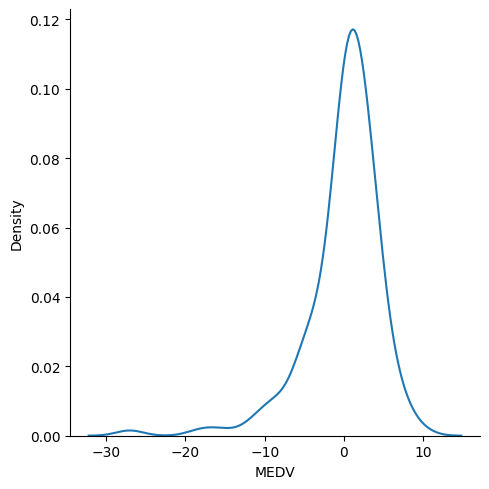

In [ ]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

In [ ]:
score2=r2_score( y_test, red_pred )

In [ ]:
score2

0.7076438632327412

#**Lasso Regression Algorithm**



Lasso Regression (Least Absolute Shrinkage and Selection Operator) is another modified version of linear regression, similar to Ridge Regression, that helps deal with **overfitting** and **feature selection**.

**The Core Idea**

Just like Ridge, Lasso adds a **penalty term** to the normal linear regression error function. But instead of penalizing the squared value of coefficients, Lasso penalizes the **absolute value** of coefficients. This difference is small mathematically, but it has a big effect: Lasso can shrink some coefficients all the way to **zero**, effectively removing those variables from the model.

**The Formula**

Normal linear regression minimizes:

Error = Sum(y_actual - y_predicted)^2

Lasso regression minimizes:

Error = Sum(y_actual - y_predicted)^2 + lambda * Sum(|coefficients|)

Where:
- lambda (regularization parameter) — controls how much penalty to apply
- coefficients are the slopes of the model
- The second term is called the **L1 penalty** (sum of absolute values of coefficients)

** Why This Helps**

- If lambda = 0, lasso regression becomes exactly the same as normal linear regression.
- As lambda increases, some coefficients shrink all the way to zero, meaning those input variables are completely removed from the model.
- This makes Lasso useful not just for preventing overfitting, but also for **automatic feature selection** — it tells you which variables actually matter.

**Lasso vs Ridge Regression**

- **Lasso** can shrink coefficients exactly to zero — removes less important variables, gives a simpler and more interpretable model.
- **Ridge** shrinks coefficients close to zero but never exactly zero — keeps all variables in the model.
- Lasso is preferred when you suspect only a few variables are actually important, out of many.
- Ridge is preferred when most variables contribute at least a little, and you don't want to remove any completely.

**Simple Analogy**

Think of Ridge as someone who reduces everyone's portion size at a buffet so nothing runs out. Lasso, on the other hand, is like someone who looks at the buffet and removes dishes entirely that nobody's really eating — leaving only the dishes people actually want.

**When to Use It**

- When you have many features and suspect only some of them are actually useful
- When you want automatic feature selection built into the model
- When you want a simpler, more interpretable model with fewer variables
- When your regular linear regression model is overfitting the training data


In [ ]:
from sklearn.linear_model import Lasso


In [ ]:
lasso=Lasso()

In [ ]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv=GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 20}
-26.76976186817788


In [ ]:
lasso_pred=lassocv.predict(x_test)

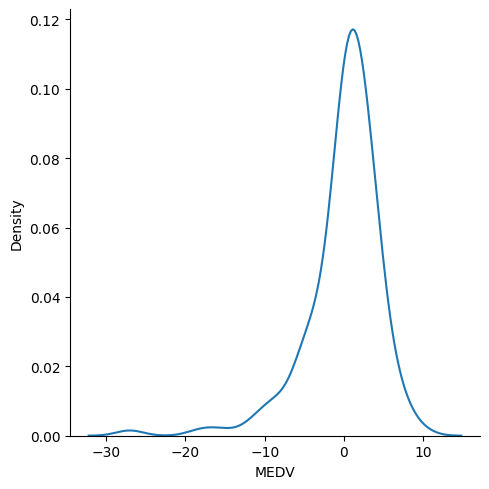

In [ ]:
import seaborn as sns
# Using displot which supports the 'kind' argument
sns.displot(lasso_pred - y_test, kind='kde')
plt.show()

In [ ]:
score3=r2_score( y_test, red_pred )

In [ ]:
score3

0.7076438632327412